In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, recall_score, confusion_matrix, roc_auc_score, make_scorer, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, ParameterGrid
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
import xgboost as xgb
from sklearn.utils import resample

In [2]:
from sdv.single_table import TVAESynthesizer
from sdv.metadata import Metadata

In [4]:
fig_save_dir = r"D:\Singapore\Alzheimer\R files\final data_new\Baseline\TVAE\figures\k9"
os.makedirs(fig_save_dir, exist_ok=True)

In [5]:
# Load the Excel file
file_path =  r"D:\Singapore\Alzheimer\R files\final data_new\Variable list-11MAY2025.xlsx"
df_Variables = pd.read_excel(file_path)

In [6]:
file_path_1 = r"D:\Singapore\Alzheimer\R files\final data_new\imoutations_diff_ks\final_data_imputed_k9.csv"
df_Data = pd.read_csv(file_path_1)
df_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 677 entries, 0 to 676
Data columns (total 38 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RID                    677 non-null    int64  
 1   AGE                    677 non-null    int64  
 2   PTGENDER               677 non-null    int64  
 3   PTEDUCAT               677 non-null    int64  
 4   PTRACCAT               677 non-null    int64  
 5   PTMARRY                677 non-null    int64  
 6   APOE4                  677 non-null    int64  
 7   FDG                    677 non-null    float64
 8   AV45                   677 non-null    float64
 9   ABETA                  677 non-null    float64
 10  TAU                    677 non-null    float64
 11  PTAU                   677 non-null    float64
 12  CDRSB                  677 non-null    float64
 13  ADAS11                 677 non-null    float64
 14  ADAS13                 677 non-null    float64
 15  ADASQ4

In [7]:
# Group features based on the "Group" column
demographics = df_Variables[df_Variables['Group'] == 'Demographic']['Predictor'].tolist()
clinical_cognitive = df_Variables[df_Variables['Group'] == 'Clinical/Cognitive']['Predictor'].tolist()
biomarker = df_Variables[df_Variables['Group'] == 'Biomarker']['Predictor'].tolist()
neuroimaging = df_Variables[df_Variables['Group'] == 'Neuroimaging']['Predictor'].tolist()

# Optional: Print or check lists
print("Demographics:", demographics)
print("Clinical/Cognitive:", clinical_cognitive)
print("Biomarker:", biomarker)
print("Neuroimaging:", neuroimaging)

Demographics: ['AGE', 'PTGENDER', 'PTEDUCAT', 'PTRACCAT', 'PTMARRY']
Clinical/Cognitive: ['CDRSB', 'ADAS11', 'ADAS13', 'ADASQ4', 'RAVLT.immediate', 'RAVLT.learning', 'RAVLT.forgetting', 'RAVLT.perc.forgetting', 'LDELTOTAL', 'TRABSCOR', 'FAQ', 'EcogPtTotal', 'MOCA_bl', 'MMSE_bl']
Biomarker: ['FDG', 'AV45', 'ABETA', 'TAU', 'PTAU']
Neuroimaging: ['Ventricles', 'Hippocampus', 'WholeBrain', 'Entorhinal', 'Fusiform', 'MidTemp', 'ICV']


In [8]:
# Group combinations
group_1 = demographics + clinical_cognitive
group_2 = demographics + biomarker
group_3 = demographics + clinical_cognitive + biomarker
group_4 = neuroimaging

In [9]:
print(f'group_1:\n', group_1)
print('*'*100)
print(f'group_2:\n', group_2)
print('*'*100)
print(f'group_3:\n', group_3)
print('*'*100)
print(f'group_4:\n', group_4)

group_1:
 ['AGE', 'PTGENDER', 'PTEDUCAT', 'PTRACCAT', 'PTMARRY', 'CDRSB', 'ADAS11', 'ADAS13', 'ADASQ4', 'RAVLT.immediate', 'RAVLT.learning', 'RAVLT.forgetting', 'RAVLT.perc.forgetting', 'LDELTOTAL', 'TRABSCOR', 'FAQ', 'EcogPtTotal', 'MOCA_bl', 'MMSE_bl']
****************************************************************************************************
group_2:
 ['AGE', 'PTGENDER', 'PTEDUCAT', 'PTRACCAT', 'PTMARRY', 'FDG', 'AV45', 'ABETA', 'TAU', 'PTAU']
****************************************************************************************************
group_3:
 ['AGE', 'PTGENDER', 'PTEDUCAT', 'PTRACCAT', 'PTMARRY', 'CDRSB', 'ADAS11', 'ADAS13', 'ADASQ4', 'RAVLT.immediate', 'RAVLT.learning', 'RAVLT.forgetting', 'RAVLT.perc.forgetting', 'LDELTOTAL', 'TRABSCOR', 'FAQ', 'EcogPtTotal', 'MOCA_bl', 'MMSE_bl', 'FDG', 'AV45', 'ABETA', 'TAU', 'PTAU']
****************************************************************************************************
group_4:
 ['Ventricles', 'Hippocampus', 'Who

In [10]:
# RF for each model
def compute_confidence_interval(metric_fn, y_true, y_score, threshold=None, n_bootstraps=1000, ci=0.95):
    stats = []
    y_true = np.array(y_true)
    y_score = np.array(y_score)
    rng = np.random.RandomState(100)

    for _ in range(n_bootstraps):
      indices = rng.randint(0, len(y_true), len(y_true))
      if len(np.unique(y_true[indices])) < 2:
        continue

      if threshold is not None:
        # Use threshold to binarize predictions
        y_pred = (y_score[indices] >= threshold).astype(int)
        value = metric_fn(y_true[indices], y_pred)
      else:
        # Use raw probabilities for metrics like AUC
        value = metric_fn(y_true[indices], y_score[indices])

      stats.append(value)

    lower = np.percentile(stats, (1 - ci) / 2 * 100)
    upper = np.percentile(stats, (1 + ci) / 2 * 100)
    return lower, upper


def run_rf_with_tuning(group_vars, df, target_column='convert_Within_3Years', group_name = None):
    X = df[group_vars]
    y = df[target_column]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=100
    )

    param_dist = {
    'n_estimators': [3, 5, 7],
    'max_depth': [8, 10, 12],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [10, 20],
    'max_features': ['sqrt', 'log2']}

    forest = RandomForestClassifier(random_state=100, class_weight='balanced')
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=100)

    def specificity_score(y_true, y_pred):
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        return tn / (tn + fp) if (tn + fp) > 0 else 0

    scoring = {
        'roc_auc': 'roc_auc',
        'f1': make_scorer(f1_score),
        'recall': make_scorer(recall_score),
        'specificity': make_scorer(specificity_score)
    }

    random_search = RandomizedSearchCV(
        forest, param_distributions=param_dist,
        cv=cv, scoring=scoring, refit='roc_auc', random_state=100
    )
    random_search.fit(X_train, y_train)
    best_params = random_search.best_params_

    # Final uncalibrated model
    uncalibrated_model = RandomForestClassifier(**best_params, random_state=100)
    uncalibrated_model.fit(X_train, y_train)

    # Apply calibration (sigmoid = Platt scaling)
    calibrated_model = CalibratedClassifierCV(uncalibrated_model, method='sigmoid', cv=5)
    calibrated_model.fit(X_train, y_train)

    y_train_proba = calibrated_model.predict_proba(X_train)[:, 1]
    y_test_proba = calibrated_model.predict_proba(X_test)[:, 1]

    # --- Youden threshold ---
    youden_thresholds = []
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model_cv = RandomForestClassifier(**best_params, random_state=100)
        model_cv_calibrated = CalibratedClassifierCV(model_cv, method='sigmoid', cv=5)
        model_cv_calibrated.fit(X_tr, y_tr)

        y_val_proba = model_cv_calibrated.predict_proba(X_val)[:, 1]
        fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)
        youden = tpr - fpr
        best_thresh = thresholds[np.argmax(youden)]
        youden_thresholds.append(best_thresh)

    optimal_threshold = np.mean(youden_thresholds)

    y_train_pred = (y_train_proba >= optimal_threshold).astype(int)
    y_test_pred = (y_test_proba >= optimal_threshold).astype(int)

    # Evaluation metrics
    test_f1 = f1_score(y_test, y_test_pred)
    test_recall = recall_score(y_test, y_test_pred)
    tn_test, fp_test, fn_test, tp_test = confusion_matrix(y_test, y_test_pred).ravel()
    test_specificity = tn_test / (tn_test + fp_test)
    test_auc = roc_auc_score(y_test, y_test_proba)


    ci_auc = compute_confidence_interval(roc_auc_score, y_test, y_test_proba, threshold=None, ci=0.95 )
    ci_f1 = compute_confidence_interval(f1_score, y_test, y_test_proba, threshold=optimal_threshold, ci=0.95)
    ci_recall = compute_confidence_interval(recall_score, y_test, y_test_proba, threshold=optimal_threshold, ci=0.95)
    ci_spec = compute_confidence_interval(specificity_score, y_test, y_test_proba, threshold=optimal_threshold, ci=0.95)


    train_f1 = f1_score(y_train, y_train_pred)
    train_recall = recall_score(y_train, y_train_pred)
    tn_train, fp_train, fn_train, tp_train = confusion_matrix(y_train, y_train_pred).ravel()
    train_specificity = tn_train / (tn_train + fp_train)
    train_auc = roc_auc_score(y_train, y_train_proba)

    cv_results = random_search.cv_results_
    best_idx = random_search.best_index_
    cv_auc = cv_results['mean_test_roc_auc'][best_idx]
    cv_f1 = cv_results['mean_test_f1'][best_idx]
    cv_recall = cv_results['mean_test_recall'][best_idx]
    cv_specificity = cv_results['mean_test_specificity'][best_idx]

    # --- Calibration Plot with 99% CI ---
    n_bins = 10
    n_bootstrap = 1000
    ci = 99
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_centers = (bin_edges[1:] + bin_edges[:-1]) / 2
    bootstrap_curves = []
    rng = np.random.RandomState(100)

    for _ in range(n_bootstrap):
        indices = rng.randint(0, len(y_test), len(y_test))
        y_bs = y_test.iloc[indices]
        p_bs = y_test_proba[indices]
        
        if len(np.unique(y_bs)) < 2:
            continue

        try:
            pt_bs, pp_bs = calibration_curve(y_bs, p_bs, n_bins=n_bins, strategy='uniform')
            interp = np.interp(bin_centers, pp_bs, pt_bs)
            bootstrap_curves.append(interp)
        except:
            continue

    bootstrap_array = np.array(bootstrap_curves)
    lower_bound = np.percentile(bootstrap_array, (100 - ci) / 2, axis=0)
    upper_bound = np.percentile(bootstrap_array, 100 - (100 - ci) / 2, axis=0)
    os.makedirs("figures", exist_ok=True)


    # --- Calibration Plot ---
    prob_true, prob_pred = calibration_curve(y_test, y_test_proba, n_bins=n_bins, strategy='uniform')
    plt.figure(figsize=(6, 6))
    plt.plot(prob_pred, prob_true, marker='o', label='Calibrated Model')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
    plt.fill_between(bin_centers, lower_bound, upper_bound, color='blue', alpha=0.2, label='99% CI')
    plt.xlabel('Predicted Probability')
    plt.ylabel('True Probability')
    plt.title(f'Calibration Plot (Test Set) for {group_name}, RF, Baseline')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.savefig(
    f"{fig_save_dir}/calibration_{group_name}_RF_Baseline.pdf",
    dpi=600,
    bbox_inches="tight")
    plt.show()
    plt.close()



    return {
        'group': group_name,
        'train_auc': train_auc,
        'train_f1': train_f1,
        'train_recall': train_recall,
        'train_specificity': train_specificity,
        'cv_auc': cv_auc,
        'cv_f1': cv_f1,
        'cv_recall': cv_recall,
        'cv_specificity': cv_specificity,
        'test_auc': test_auc,
        'test_f1': test_f1,
        'test_recall': test_recall,
        'test_specificity': test_specificity,
        'optimal_threshold': optimal_threshold,
        'best_params': best_params,
        'ci_auc': ci_auc,
        'ci_f1': ci_f1,
        'ci_recall': ci_recall,
        'ci_specificity': ci_spec
    }


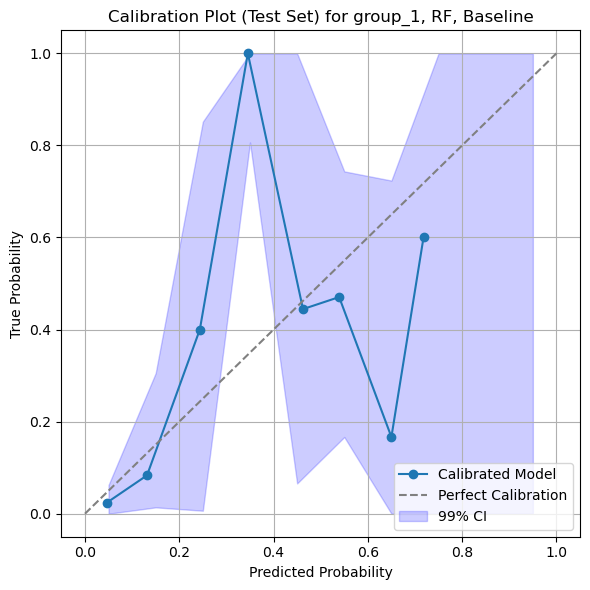

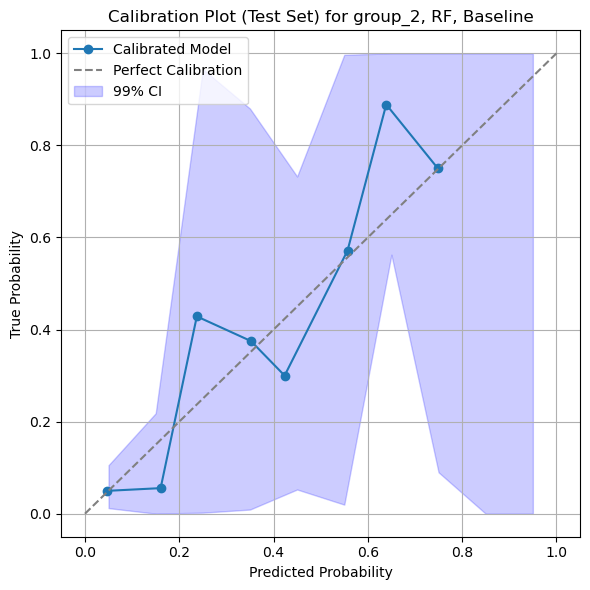

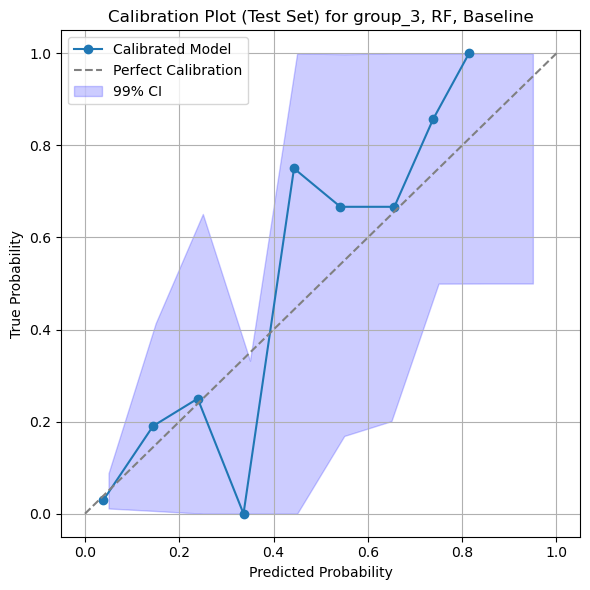

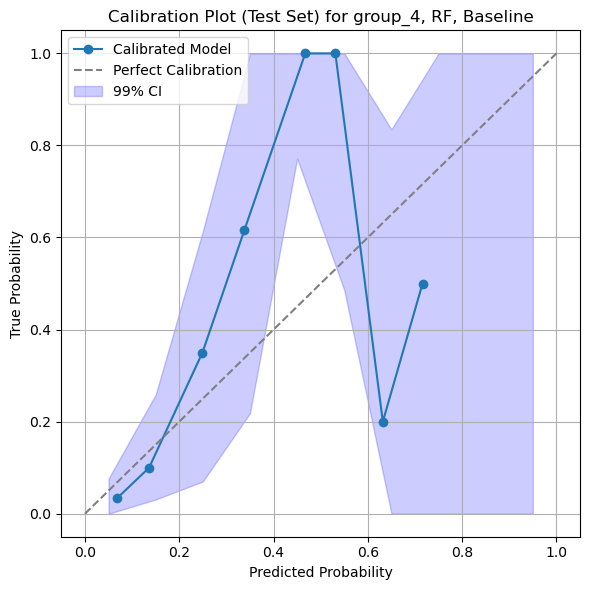

In [11]:
results_1 = run_rf_with_tuning(group_1, df_Data, group_name="group_1")
results_2 = run_rf_with_tuning(group_2, df_Data, group_name="group_2")
results_3 = run_rf_with_tuning(group_3, df_Data, group_name="group_3")
results_4 = run_rf_with_tuning(group_4, df_Data, group_name="group_4")

In [12]:
# Gather the results
all_results = [results_1, results_2, results_3, results_4]

# Create the summary list
summary_data = []
for i, res in enumerate(all_results, start=1):
    summary_data.append({
        "Group": res.get("group", f"group_{i}"),
        "Method": res.get("method", "RF"),
        "Multiplier": res.get("sample_multiplier", "baseline"),

        "Train AUC": round(res["train_auc"], 3),
        "CV AUC": round(res["cv_auc"], 3),
        "Test AUC": round(res["test_auc"], 3),
        "AUC CI Lower": round(res["ci_auc"][0], 3),
        "AUC CI Upper": round(res["ci_auc"][1], 3)})


# Convert to DataFrame
summary_df_baseline_rf_auc = pd.DataFrame(summary_data)
print(summary_df_baseline_rf_auc.to_markdown(index=False))

| Group   | Method   | Multiplier   |   Train AUC |   CV AUC |   Test AUC |   AUC CI Lower |   AUC CI Upper |
|:--------|:---------|:-------------|------------:|---------:|-----------:|---------------:|---------------:|
| group_1 | RF       | baseline     |       0.951 |    0.891 |      0.866 |          0.81  |          0.917 |
| group_2 | RF       | baseline     |       0.928 |    0.899 |      0.885 |          0.822 |          0.942 |
| group_3 | RF       | baseline     |       0.947 |    0.916 |      0.898 |          0.829 |          0.956 |
| group_4 | RF       | baseline     |       0.93  |    0.832 |      0.868 |          0.79  |          0.934 |


In [13]:
# Gather the results
all_results = [results_1, results_2, results_3, results_4]

# Create the summary list
summary_data = []
for i, res in enumerate(all_results, start=1):
    summary_data.append({
        "Group": res.get("group", f"group_{i}"),
        "Method": res.get("method", "RF"),
        "Multiplier": res.get("sample_multiplier", "baseline"),


        "Train Recall": round(res["train_recall"], 3),
        "CV Recall": round(res["cv_recall"], 3),
        "Test Recall": round(res["test_recall"], 3),
        "Recall CI Lower": round(res["ci_recall"][0], 3),
        "Recall CI Upper": round(res["ci_recall"][1], 3)})



# Convert to DataFrame
summary_df_baseline_rf_recall = pd.DataFrame(summary_data)
print(summary_df_baseline_rf_recall.to_markdown(index=False))

| Group   | Method   | Multiplier   |   Train Recall |   CV Recall |   Test Recall |   Recall CI Lower |   Recall CI Upper |
|:--------|:---------|:-------------|---------------:|------------:|--------------:|------------------:|------------------:|
| group_1 | RF       | baseline     |          0.96  |       0.84  |         0.844 |             0.7   |             0.962 |
| group_2 | RF       | baseline     |          0.827 |       0.827 |         0.781 |             0.613 |             0.914 |
| group_3 | RF       | baseline     |          0.88  |       0.853 |         0.75  |             0.586 |             0.895 |
| group_4 | RF       | baseline     |          0.853 |       0.613 |         0.781 |             0.613 |             0.92  |


In [14]:
# Gather the results
all_results = [results_1, results_2, results_3, results_4]

# Create the summary list
summary_data = []
for i, res in enumerate(all_results, start=1):
    summary_data.append({
        "Group": res.get("group", f"group_{i}"),
        "Method": res.get("method", "RF"),
        "Multiplier": res.get("sample_multiplier", "baseline"),

        "Train Specificity": round(res["train_specificity"], 3),
        "CV Specificity": round(res["cv_specificity"], 3),
        "Test Specificity": round(res["test_specificity"], 3),
        "Spec CI Lower": round(res["ci_specificity"][0], 3),
        "Spec CI Upper": round(res["ci_specificity"][1], 3)
    })


# Convert to DataFrame
summary_df_baseline_rf_spec = pd.DataFrame(summary_data)
print(summary_df_baseline_rf_spec.to_markdown(index=False))

| Group   | Method   | Multiplier   |   Train Specificity |   CV Specificity |   Test Specificity |   Spec CI Lower |   Spec CI Upper |
|:--------|:---------|:-------------|--------------------:|-----------------:|-------------------:|----------------:|----------------:|
| group_1 | RF       | baseline     |               0.829 |            0.819 |              0.802 |           0.74  |           0.861 |
| group_2 | RF       | baseline     |               0.852 |            0.812 |              0.826 |           0.767 |           0.881 |
| group_3 | RF       | baseline     |               0.874 |            0.827 |              0.866 |           0.814 |           0.916 |
| group_4 | RF       | baseline     |               0.829 |            0.852 |              0.843 |           0.787 |           0.895 |


In [15]:
# Gather the results
all_results = [results_1, results_2, results_3, results_4]

# Create the summary list
summary_data = []
for i, res in enumerate(all_results, start=1):
    summary_data.append({
        "Group": res.get("group", f"group_{i}"),
        "Method": res.get("method", "RF"),
        "Multiplier": res.get("sample_multiplier", "baseline"),

        "Train F1": round(res["train_f1"], 3),
        "CV F1": round(res["cv_f1"], 3),
        "Test F1": round(res["test_f1"], 3),
        "F1 CI Lower": round(res["ci_f1"][0], 3),
        "F1 CI Upper": round(res["ci_f1"][1], 3),
         #"Best Params": str(res["best_params"])
    })


# Convert to DataFrame
summary_df_baseline_rf_f1 = pd.DataFrame(summary_data)
print(summary_df_baseline_rf_f1.to_markdown(index=False))

| Group   | Method   | Multiplier   |   Train F1 |   CV F1 |   Test F1 |   F1 CI Lower |   F1 CI Upper |
|:--------|:---------|:-------------|-----------:|--------:|----------:|--------------:|--------------:|
| group_1 | RF       | baseline     |      0.67  |   0.604 |     0.581 |         0.451 |         0.692 |
| group_2 | RF       | baseline     |      0.633 |   0.587 |     0.575 |         0.432 |         0.702 |
| group_3 | RF       | baseline     |      0.691 |   0.616 |     0.608 |         0.456 |         0.731 |
| group_4 | RF       | baseline     |      0.618 |   0.514 |     0.595 |         0.444 |         0.718 |


In [16]:
# Gather the results
all_results = [results_1, results_2, results_3, results_4]

# Create the summary list
summary_data = []
for i, res in enumerate(all_results, start=1):
    summary_data.append({
        "Group": res.get("group", f"group_{i}"),
        "Method": res.get("method", "RF"),
        "Multiplier": res.get("sample_multiplier", "baseline"),
        "Best Params": str(res["best_params"])
    })


# Convert to DataFrame
summary_df_baseline_rf_bestparams = pd.DataFrame(summary_data)
print(summary_df_baseline_rf_bestparams.to_markdown(index=False))

| Group   | Method   | Multiplier   | Best Params                                                                                                   |
|:--------|:---------|:-------------|:--------------------------------------------------------------------------------------------------------------|
| group_1 | RF       | baseline     | {'n_estimators': 5, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 10} |
| group_2 | RF       | baseline     | {'n_estimators': 7, 'min_samples_split': 10, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'max_depth': 8}  |
| group_3 | RF       | baseline     | {'n_estimators': 7, 'min_samples_split': 10, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'max_depth': 8}  |
| group_4 | RF       | baseline     | {'n_estimators': 7, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 10}  |


In [17]:
# XGBoost for each model
def compute_confidence_interval(metric_fn, y_true, y_score, threshold=None, n_bootstraps=1000, ci=0.95):
    stats = []
    y_true = np.array(y_true)
    y_score = np.array(y_score)
    rng = np.random.RandomState(100)

    for _ in range(n_bootstraps):
      indices = rng.randint(0, len(y_true), len(y_true))
      if len(np.unique(y_true[indices])) < 2:
        continue

      if threshold is not None:
        # Use threshold to binarize predictions
        y_pred = (y_score[indices] >= threshold).astype(int)
        value = metric_fn(y_true[indices], y_pred)
      else:
        # Use raw probabilities for metrics like AUC
        value = metric_fn(y_true[indices], y_score[indices])

      stats.append(value)

    lower = np.percentile(stats, (1 - ci) / 2 * 100)
    upper = np.percentile(stats, (1 + ci) / 2 * 100)
    return lower, upper


def run_xgboost_with_tuning(group_vars, df, target_column='convert_Within_3Years', group_name = None):
    X = df[group_vars]
    y = df[target_column]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=100
    )
        # -------------------------------
    # SAVE THE SPLITS HERE
    # -------------------------------
    X_train.to_csv(f"{group_name}_X_train.csv", index=False)
    X_test.to_csv(f"{group_name}_X_test.csv", index=False)

    # y_train/y_test are pandas Series → convert to DataFrame
    y_train.to_frame().to_csv(f"{group_name}_y_train.csv", index=False)
    y_test.to_frame().to_csv(f"{group_name}_y_test.csv", index=False)

    param_dist = {
        'n_estimators': [50],
        'max_depth': [2],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.7],
        'colsample_bytree': [0.7],
        'gamma': [0, 0.1],
        'reg_alpha': [0, 0.5, 1],
        'reg_lambda': [1.0, 2, 3]
    }
    neg_count = (y_train == 0).sum()
    pos_count = (y_train == 1).sum()
    scale_pos_weight = neg_count / pos_count
    base_model = xgb.XGBClassifier(eval_metric='logloss', random_state=100, scale_pos_weight=scale_pos_weight)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=100)

    def specificity_score(y_true, y_pred):
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        return tn / (tn + fp) if (tn + fp) > 0 else 0

    scoring = {
        'roc_auc': 'roc_auc',
        'f1': make_scorer(f1_score),
        'recall': make_scorer(recall_score),
        'specificity': make_scorer(specificity_score)
    }

    random_search = RandomizedSearchCV(
        base_model, param_distributions=param_dist,
        cv=cv, scoring=scoring, refit='roc_auc', random_state=100
    )
    random_search.fit(X_train, y_train)
    best_params = random_search.best_params_

    # Final uncalibrated model
    uncalibrated_model = xgb.XGBClassifier(**best_params, random_state=100)
    

    # Apply calibration (sigmoid = Platt scaling)
    calibrated_model = CalibratedClassifierCV(uncalibrated_model, method='isotonic', cv=3)
    calibrated_model.fit(X_train, y_train)

    y_train_proba = calibrated_model.predict_proba(X_train)[:, 1]
    y_test_proba = calibrated_model.predict_proba(X_test)[:, 1]

    # --- Youden threshold ---
    youden_thresholds = []
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model_cv = xgb.XGBClassifier(**best_params, random_state=100)
        model_cv_calibrated = CalibratedClassifierCV(model_cv, method='isotonic', cv=3)
        model_cv_calibrated.fit(X_tr, y_tr)

        y_val_proba = model_cv_calibrated.predict_proba(X_val)[:, 1]
        fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)
        youden = tpr - fpr
        best_thresh = thresholds[np.argmax(youden)]
        youden_thresholds.append(best_thresh)

    optimal_threshold = np.mean(youden_thresholds)

    y_train_pred = (y_train_proba >= optimal_threshold).astype(int)
    y_test_pred = (y_test_proba >= optimal_threshold).astype(int)

    # Evaluation metrics
    test_f1 = f1_score(y_test, y_test_pred)
    test_recall = recall_score(y_test, y_test_pred)
    tn_test, fp_test, fn_test, tp_test = confusion_matrix(y_test, y_test_pred).ravel()
    test_specificity = tn_test / (tn_test + fp_test)
    test_auc = roc_auc_score(y_test, y_test_proba)

    ci_auc = compute_confidence_interval(roc_auc_score, y_test, y_test_proba, threshold=None)
    ci_f1 = compute_confidence_interval(f1_score, y_test, y_test_proba, threshold=optimal_threshold)
    ci_recall = compute_confidence_interval(recall_score, y_test, y_test_proba, threshold=optimal_threshold)
    ci_spec = compute_confidence_interval(specificity_score, y_test, y_test_proba, threshold=optimal_threshold)

    train_f1 = f1_score(y_train, y_train_pred)
    train_recall = recall_score(y_train, y_train_pred)
    tn_train, fp_train, fn_train, tp_train = confusion_matrix(y_train, y_train_pred).ravel()
    train_specificity = tn_train / (tn_train + fp_train)
    train_auc = roc_auc_score(y_train, y_train_proba)

    cv_results = random_search.cv_results_
    best_idx = random_search.best_index_
    cv_auc = cv_results['mean_test_roc_auc'][best_idx]
    cv_f1 = cv_results['mean_test_f1'][best_idx]
    cv_recall = cv_results['mean_test_recall'][best_idx]
    cv_specificity = cv_results['mean_test_specificity'][best_idx]



    # --- Calibration Plot with 99% CI ---
    n_bins = 10
    n_bootstrap = 1000
    ci = 99
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_centers = (bin_edges[1:] + bin_edges[:-1]) / 2
    bootstrap_curves = []
    rng = np.random.RandomState(100)

    for _ in range(n_bootstrap):
        indices = rng.randint(0, len(y_test), len(y_test))
        y_bs = y_test.iloc[indices]
        p_bs = y_test_proba[indices]
        
        if len(np.unique(y_bs)) < 2:
            continue

        try:
            pt_bs, pp_bs = calibration_curve(y_bs, p_bs, n_bins=n_bins, strategy='uniform')
            interp = np.interp(bin_centers, pp_bs, pt_bs)
            bootstrap_curves.append(interp)
        except:
            continue

    bootstrap_array = np.array(bootstrap_curves)
    lower_bound = np.percentile(bootstrap_array, (100 - ci) / 2, axis=0)
    upper_bound = np.percentile(bootstrap_array, 100 - (100 - ci) / 2, axis=0)

    # --- Calibration Plot ---
    prob_true, prob_pred = calibration_curve(y_test, y_test_proba, n_bins=n_bins, strategy='uniform')
    plt.figure(figsize=(6, 6))
    plt.plot(prob_pred, prob_true, marker='o', label='Calibrated Model')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
    plt.fill_between(bin_centers, lower_bound, upper_bound, color='blue', alpha=0.2, label='99% CI')
    plt.xlabel('Predicted Probability')
    plt.ylabel('True Probability')
    plt.title(f'Calibration Plot (Test Set) for {group_name}, XGBoost, Baseline')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.savefig(f"{fig_save_dir}/calibration_{group_name}_XGBoost_Baeline.pdf",dpi=600,bbox_inches="tight")
    plt.show()
    plt.close()

    return {
        'group': group_name,
        'train_auc': train_auc,
        'train_f1': train_f1,
        'train_recall': train_recall,
        'train_specificity': train_specificity,
        'cv_auc': cv_auc,
        'cv_f1': cv_f1,
        'cv_recall': cv_recall,
        'cv_specificity': cv_specificity,
        'test_auc': test_auc,
        'test_f1': test_f1,
        'test_recall': test_recall,
        'test_specificity': test_specificity,
        'optimal_threshold': optimal_threshold,
        'best_params': best_params,
        'ci_auc': ci_auc,
        'ci_f1': ci_f1,
        'ci_recall': ci_recall,
        'ci_specificity': ci_spec
    }


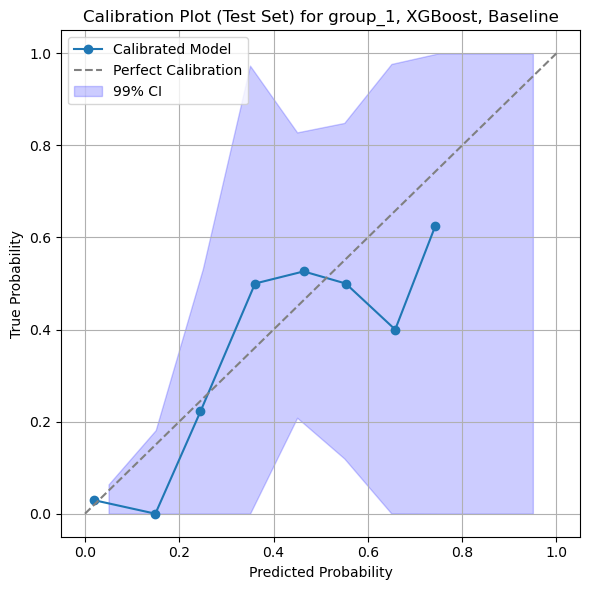

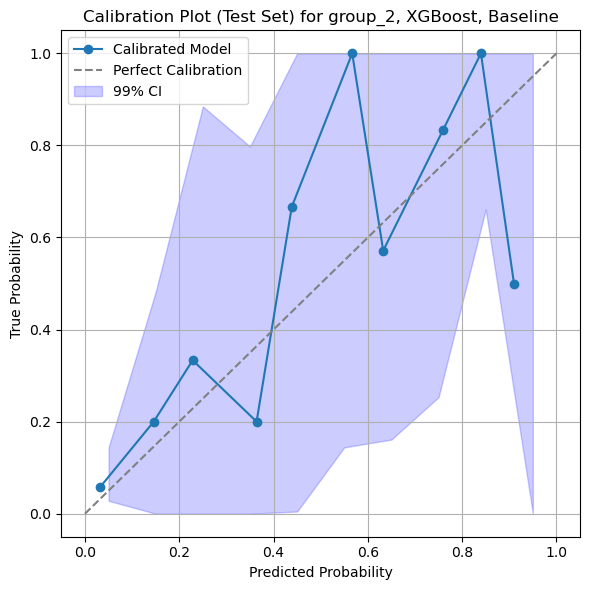

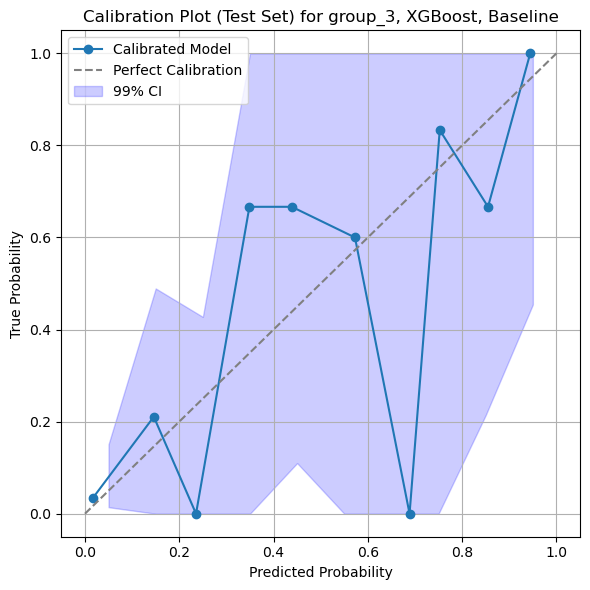

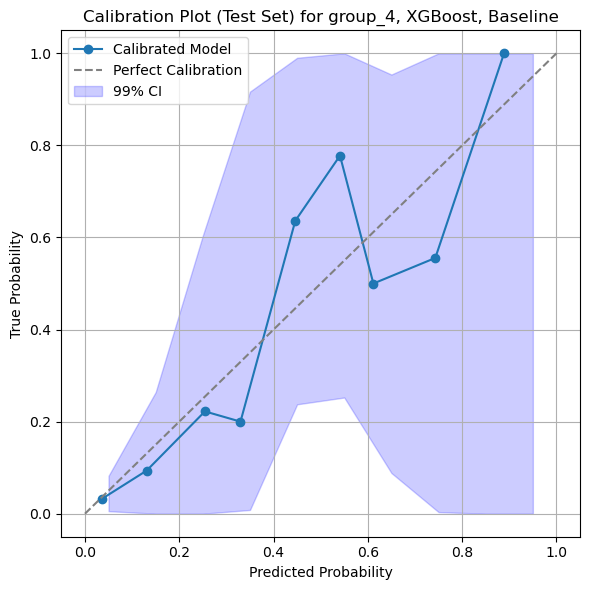

In [18]:
results_1 = run_xgboost_with_tuning(group_1, df_Data, group_name="group_1")
results_2 = run_xgboost_with_tuning(group_2, df_Data, group_name="group_2")
results_3 = run_xgboost_with_tuning(group_3, df_Data, group_name="group_3")
results_4 = run_xgboost_with_tuning(group_4, df_Data, group_name="group_4")

In [19]:
# Gather the results
all_results = [results_1, results_2, results_3, results_4]

# Create the summary list
summary_data = []
for i, res in enumerate(all_results, start=1):
    summary_data.append({
        "Group": res.get("group", f"group_{i}"),
        "Method": res.get("method", "XGBoost"),
        "Multiplier": res.get("sample_multiplier", "baseline"),

        "Train AUC": round(res["train_auc"], 3),
        "CV AUC": round(res["cv_auc"], 3),
        "Test AUC": round(res["test_auc"], 3),
        "AUC CI Lower": round(res["ci_auc"][0], 3),
        "AUC CI Upper": round(res["ci_auc"][1], 3)})

# Convert to DataFrame
summary_df_baseline_xgb_auc = pd.DataFrame(summary_data)
print(summary_df_baseline_xgb_auc.to_markdown(index=False))

| Group   | Method   | Multiplier   |   Train AUC |   CV AUC |   Test AUC |   AUC CI Lower |   AUC CI Upper |
|:--------|:---------|:-------------|------------:|---------:|-----------:|---------------:|---------------:|
| group_1 | XGBoost  | baseline     |       0.961 |    0.906 |      0.889 |          0.833 |          0.938 |
| group_2 | XGBoost  | baseline     |       0.959 |    0.914 |      0.892 |          0.83  |          0.942 |
| group_3 | XGBoost  | baseline     |       0.978 |    0.936 |      0.907 |          0.84  |          0.961 |
| group_4 | XGBoost  | baseline     |       0.935 |    0.864 |      0.885 |          0.815 |          0.945 |


In [20]:
# Gather the results
all_results = [results_1, results_2, results_3, results_4]

# Create the summary list
summary_data = []
for i, res in enumerate(all_results, start=1):
    summary_data.append({
        "Group": res.get("group", f"group_{i}"),
        "Method": res.get("method", "XGBoost"),
        "Multiplier": res.get("sample_multiplier", "baseline"),

 
        "Train Recall": round(res["train_recall"], 3),
        "CV Recall": round(res["cv_recall"], 3),
        "Test Recall": round(res["test_recall"], 3),
        "Recall CI Lower": round(res["ci_recall"][0], 3),
        "Recall CI Upper": round(res["ci_recall"][1], 3)})
# Convert to DataFrame
summary_df_baseline_xgb_recall = pd.DataFrame(summary_data)
print(summary_df_baseline_xgb_recall.to_markdown(index=False))

| Group   | Method   | Multiplier   |   Train Recall |   CV Recall |   Test Recall |   Recall CI Lower |   Recall CI Upper |
|:--------|:---------|:-------------|---------------:|------------:|--------------:|------------------:|------------------:|
| group_1 | XGBoost  | baseline     |          0.947 |       0.853 |         0.875 |             0.75  |             0.973 |
| group_2 | XGBoost  | baseline     |          0.84  |       0.853 |         0.594 |             0.407 |             0.767 |
| group_3 | XGBoost  | baseline     |          0.893 |       0.867 |         0.719 |             0.55  |             0.879 |
| group_4 | XGBoost  | baseline     |          0.8   |       0.693 |         0.781 |             0.607 |             0.919 |


In [21]:
# Gather the results
all_results = [results_1, results_2, results_3, results_4]

# Create the summary list
summary_data = []
for i, res in enumerate(all_results, start=1):
    summary_data.append({
        "Group": res.get("group", f"group_{i}"),
        "Method": res.get("method", "XGBoost"),
        "Multiplier": res.get("sample_multiplier", "baseline"),

        "Train Specificity": round(res["train_specificity"], 3),
        "CV Specificity": round(res["cv_specificity"], 3),
        "Test Specificity": round(res["test_specificity"], 3),
        "Spec CI Lower": round(res["ci_specificity"][0], 3),
        "Spec CI Upper": round(res["ci_specificity"][1], 3)})
# Convert to DataFrame
summary_df_baseline_xgb_spec = pd.DataFrame(summary_data)
print(summary_df_baseline_xgb_spec.to_markdown(index=False))

| Group   | Method   | Multiplier   |   Train Specificity |   CV Specificity |   Test Specificity |   Spec CI Lower |   Spec CI Upper |
|:--------|:---------|:-------------|--------------------:|-----------------:|-------------------:|----------------:|----------------:|
| group_1 | XGBoost  | baseline     |               0.849 |            0.824 |              0.849 |           0.793 |           0.903 |
| group_2 | XGBoost  | baseline     |               0.917 |            0.852 |              0.93  |           0.889 |           0.966 |
| group_3 | XGBoost  | baseline     |               0.925 |            0.867 |              0.942 |           0.908 |           0.975 |
| group_4 | XGBoost  | baseline     |               0.897 |            0.794 |              0.895 |           0.844 |           0.94  |


In [22]:
# Gather the results
all_results = [results_1, results_2, results_3, results_4]

# Create the summary list
summary_data = []
for i, res in enumerate(all_results, start=1):
    summary_data.append({
        "Group": res.get("group", f"group_{i}"),
        "Method": res.get("method", "XGBoost"),
        "Multiplier": res.get("sample_multiplier", "baseline"),

        "Train F1": round(res["train_f1"], 3),
        "CV F1": round(res["cv_f1"], 3),
        "Test F1": round(res["test_f1"], 3),
        "F1 CI Lower": round(res["ci_f1"][0], 3),
        "F1 CI Upper": round(res["ci_f1"][1], 3),
        #"Best Params": str(res["best_params"])
        
    })

# Convert to DataFrame
summary_df_baseline_xgb_f1 = pd.DataFrame(summary_data)
print(summary_df_baseline_xgb_f1.to_markdown(index=False))

| Group   | Method   | Multiplier   |   Train F1 |   CV F1 |   Test F1 |   F1 CI Lower |   F1 CI Upper |
|:--------|:---------|:-------------|-----------:|--------:|----------:|--------------:|--------------:|
| group_1 | XGBoost  | baseline     |      0.689 |   0.613 |     0.651 |         0.511 |         0.762 |
| group_2 | XGBoost  | baseline     |      0.737 |   0.646 |     0.603 |         0.428 |         0.738 |
| group_3 | XGBoost  | baseline     |      0.779 |   0.674 |     0.708 |         0.565 |         0.822 |
| group_4 | XGBoost  | baseline     |      0.682 |   0.495 |     0.667 |         0.508 |         0.786 |


In [23]:
# Gather the results
all_results = [results_1, results_2, results_3, results_4]

# Create the summary list
summary_data = []
for i, res in enumerate(all_results, start=1):
    summary_data.append({
        "Group": res.get("group", f"group_{i}"),
        "Method": res.get("method", "XGBoost"),
        "Multiplier": res.get("sample_multiplier", "baseline"),
        "Best Params": str(res["best_params"])
        
    })
# Convert to DataFrame
summary_df_baseline_xgb_bestparams = pd.DataFrame(summary_data)
print(summary_df_baseline_xgb_bestparams.to_markdown(index=False))    

| Group   | Method   | Multiplier   | Best Params                                                                                                                                          |
|:--------|:---------|:-------------|:-----------------------------------------------------------------------------------------------------------------------------------------------------|
| group_1 | XGBoost  | baseline     | {'subsample': 0.7, 'reg_lambda': 3, 'reg_alpha': 0, 'n_estimators': 50, 'max_depth': 2, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7} |
| group_2 | XGBoost  | baseline     | {'subsample': 0.7, 'reg_lambda': 3, 'reg_alpha': 0, 'n_estimators': 50, 'max_depth': 2, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7} |
| group_3 | XGBoost  | baseline     | {'subsample': 0.7, 'reg_lambda': 3, 'reg_alpha': 0, 'n_estimators': 50, 'max_depth': 2, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7} |
| group_4 | XGBoost  | baseline     | {'subsample': 0.7